In [2]:
import pickle

# ---- load MVN1 (igraph) ----
with open("/home/admin/Ana/MicroBrain/MVN1_corrected_SI.pkl", "rb") as f:
    Gm = pickle.load(f)

# ---- load HPC outgeom dict ----
with open("/home/admin/Ana/MicroBrain/output/um/graph_18_OutGeom_Hcut2_um.pkl", "rb") as f:
    data = pickle.load(f)

# ---- extract graph ----
Gp = data["graph"]   # igraph graph with outgeom attributes


=== VOX PKL ===
geom[x]           min=1076.923  max=1323.077  shape=(18694,)  dtype=float64
geom[y]           min=3276.923  max=3523.077  shape=(18694,)  dtype=float64
geom[z]           min=1420.000  max=1580.000  shape=(18694,)  dtype=float64
coords_img[x]     min=1076.923  max=1323.077  shape=(720,)  dtype=float64
coords_img[y]     min=3276.923  max=3523.077  shape=(720,)  dtype=float64
coords_img[z]     min=1420.000  max=1580.000  shape=(720,)  dtype=float64

=== UM PKL (geom_R / vertex_R) ===
geom_R[x_R]       min=1750.000  max=2150.000  shape=(18694,)  dtype=float32
geom_R[y_R]       min=5325.000  max=5725.000  shape=(18694,)  dtype=float32
geom_R[z_R]       min=3550.000  max=3950.000  shape=(18694,)  dtype=float32
coords_R[x]       min=1750.000  max=2150.000  shape=(720,)  dtype=float32
coords_R[y]       min=5325.000  max=5725.000  shape=(720,)  dtype=float32
coords_R[z]       min=3550.000  max=3950.000  shape=(720,)  dtype=float32

=== Rough scale ratio (max) ===
x ratio: 1.625

## Verifying atlas conversion (vox -> um)

In [3]:

import numpy as np

# --- HPC: verify atlas diameter conversion ---
da  = np.asarray(Gp.es["diameter_atlas"], float)
dar = np.asarray(Gp.es["diameter_atlas_R"], float)
m = np.isfinite(da) & np.isfinite(dar)

max_abs = float(np.max(np.abs(dar[m] - 25*da[m])))
med_abs = float(np.median(np.abs(dar[m] - 25*da[m])))

print("Check: diameter_atlas_R == 25 * diameter_atlas")
print("  max abs error:", max_abs)
print("  median abs error:", med_abs)

# --- quick summary (µm fields to use) ---
d_h = np.asarray(Gp.es["diameter_atlas_R"], float)
l_h = np.asarray(Gp.es["length_R"], float)
d_h = d_h[np.isfinite(d_h)]
l_h = l_h[np.isfinite(l_h)]


print("\nHPC (µm) medians:")
print("  diameter_atlas_R median (µm):", float(np.median(d_h)))
print("  length_R         median (µm):", float(np.median(l_h)))

Check: diameter_atlas_R == 25 * diameter_atlas
  max abs error: 9.5367431640625e-07
  median abs error: 2.384185791015625e-07

HPC (µm) medians:
  diameter_atlas_R median (µm): 12.736600875854492
  length_R         median (µm): 170.77501678466797


## Capillaries in atlas resolution

Defining a capillary threshold (6um). In atlas at 25 um/voxel that equals diameter_atlas = 6/25 = 0.24 vox
If there are not many values <0.24 vox in HPC it means that atlas can't resolve fine capilaries

In [4]:
import numpy as np

# MVN1 (SI -> µm)
d_m = np.asarray(Gm.es["diameter"], float) * 1e6
d_m = d_m[np.isfinite(d_m)]

# HPC atlas (vox and µm)
d_a  = np.asarray(Gp.es["diameter_atlas"], float)
d_ar = np.asarray(Gp.es["diameter_atlas_R"], float)
d_a  = d_a[np.isfinite(d_a)]
d_ar = d_ar[np.isfinite(d_ar)]

cap_um = 6.0
cap_vox_atlas = cap_um / 25.0  # 0.24 vox

print("MVN1: fraction <= 6 µm:", np.mean(d_m <= cap_um))
print("HPC atlas: fraction <= 0.24 atlas-vox:", np.mean(d_a <= cap_vox_atlas))
print("HPC atlas: fraction <= 6 µm (diameter_atlas_R):", np.mean(d_ar <= cap_um))

MVN1: fraction <= 6 µm: 0.9485543865462679
HPC atlas: fraction <= 0.24 atlas-vox: 0.0008460236886632825
HPC atlas: fraction <= 6 µm (diameter_atlas_R): 0.0008460236886632825


- We can see how MVN1 has aprox 95% of vessels under 6 um, therefore is a fine capillary network. 

- For HPC < 0.24 vox are only 0.08%, therefore not fine capillaries represented in atlas

Conclusion: The atlas-derived diameters cannot resolve capillary-scale vessels (<6 µm), as they fall below the atlas voxel resolution (25 µm). capillary calibers are sub-voxel

In [5]:
med_m = np.median(d_m)
med_h = np.median(d_ar)

print("Median diameter (µm): MVN1 =", med_m, "HPC atlas =", med_h)
print("Resolvability ratio vs atlas voxel (25 µm):")
print("  MVN1 median / 25 =", med_m/25.0)
print("  HPC  median / 25 =", med_h/25.0)
print("Median ratio (HPC/MVN1):", np.median(d_h) / np.median(d_m))

Median diameter (µm): MVN1 = 3.8926928043333326 HPC atlas = 12.736600875854492
Resolvability ratio vs atlas voxel (25 µm):
  MVN1 median / 25 = 0.15570771217333332
  HPC  median / 25 = 0.5094640350341797
Median ratio (HPC/MVN1): 3.2719255065994806


The median atlas-derived diameter corresponds to ~0.5 atlas voxels, highlighting the limited effective resolution for microvascular calibers.

## Comparison MVN1 vs HPC

In [6]:
from scipy.stats import ks_2samp

# MVN1 in µm
d_m = np.asarray(Gm.es["diameter"], float) * 1e6
l_m = np.asarray(Gm.es["length"], float)   * 1e6
d_m = d_m[np.isfinite(d_m)]
l_m = l_m[np.isfinite(l_m)]

# HPC in µm (atlas diameter + converted tortuous length)
d_h = np.asarray(Gp.es["diameter_atlas_R"], float)
l_h = np.asarray(Gp.es["length_R"], float)
d_h = d_h[np.isfinite(d_h)]
l_h = l_h[np.isfinite(l_h)]

print("KS diameter:", ks_2samp(d_m, d_h))
print("KS length  :", ks_2samp(l_m, l_h))

KS diameter: KstestResult(statistic=0.9814504873239425, pvalue=0.0)
KS length  : KstestResult(statistic=0.49858809152447015, pvalue=5.372694072721558e-248)


Diameter KS is close to 1, the distributions are nearly completely separated. 

Lenght KS is aprox 0.5, also strong, but less extrema than diameter.

This shows how diameter distributions of MVN1 and HPC are statistically incompatible

## Extra check of data

In [7]:
import numpy as np
from scipy.stats import ks_2samp

def summarize(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return {
        "n": x.size,
        "p5": np.percentile(x, 5),
        "median": np.median(x),
        "p95": np.percentile(x, 95),
    }

# --- MVN1 in µm ---
d_m = np.asarray(Gm.es["diameter"], float) * 1e6
l_m = np.asarray(Gm.es["length"], float)   * 1e6

# --- HPC already in µm ---
d_h = np.asarray(Gp.es["diameter"], float)
l_h = np.asarray(Gp.es["length"], float)

# clean
d_m = d_m[np.isfinite(d_m)]; d_h = d_h[np.isfinite(d_h)]
l_m = l_m[np.isfinite(l_m)]; l_h = l_h[np.isfinite(l_h)]

print("DIAMETER (µm)")
print(" MVN1:", summarize(d_m))
print(" HPC :", summarize(d_h))
print(" KS test diameter:", ks_2samp(d_m, d_h))

print("\nLENGTH (µm)")
print(" MVN1:", summarize(l_m))
print(" HPC :", summarize(l_h))
print(" KS test length:", ks_2samp(l_m, l_h))

DIAMETER (µm)
 MVN1: {'n': 12071, 'p5': 2.9806566238000003, 'median': 3.8926928043333326, 'p95': 6.0519733428}
 HPC : {'n': 1182, 'p5': 5.656854152679443, 'median': 6.633249759674072, 'p95': 10.0}
 KS test diameter: KstestResult(statistic=0.8778204001956277, pvalue=0.0)

LENGTH (µm)
 MVN1: {'n': 12071, 'p5': 12.254930460845696, 'median': 51.858392966329326, 'p95': 176.66977349368608}
 HPC : {'n': 1182, 'p5': 3.3012660264968874, 'median': 19.566696166992188, 'p95': 68.07805175781252}
 KS test length: KstestResult(statistic=0.44283526360741254, pvalue=6.188052877921087e-193)


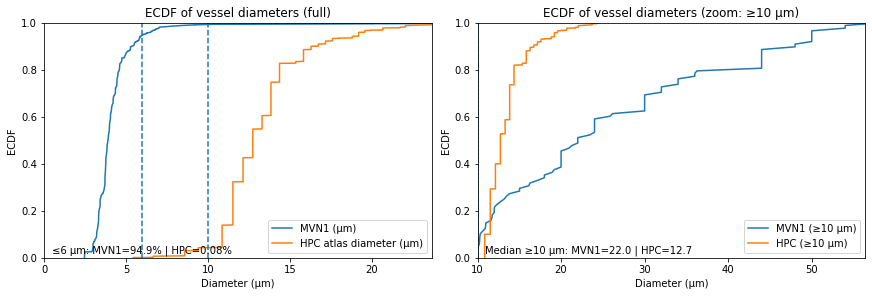

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def ecdf(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, x.size + 1) / x.size if x.size else np.array([])
    return x, y

# -------------------------
# Build comparable arrays (µm)
# -------------------------
# MVN1 is SI -> µm
d_m = np.asarray(Gm.es["diameter"], float) * 1e6
d_m = d_m[np.isfinite(d_m)]

# HPC uses atlas-derived diameter in µm
d_h = np.asarray(Gp.es["diameter_atlas_R"], float)
d_h = d_h[np.isfinite(d_h)]

# thresholds
cap_thr = 6.0
zoom_thr = 10.0

# -------------------------
# ECDFs
# -------------------------
xm, ym = ecdf(d_m)
xh, yh = ecdf(d_h)

# zoomed (resolvable-ish range)
d_mz = d_m[d_m >= zoom_thr]
d_hz = d_h[d_h >= zoom_thr]
xmz, ymz = ecdf(d_mz)
xhz, yhz = ecdf(d_hz)

# -------------------------
# Plot (two panels)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Panel A: full CDF
ax = axes[0]
ax.plot(xm, ym, label="MVN1 (µm)")
ax.plot(xh, yh, label="HPC atlas diameter (µm)")
ax.axvline(cap_thr, linestyle="--")
ax.axvline(zoom_thr, linestyle="--")
ax.set_title("ECDF of vessel diameters (full)")
ax.set_xlabel("Diameter (µm)")
ax.set_ylabel("ECDF")
ax.set_xlim(0, max(np.percentile(d_h, 99.5), np.percentile(d_m, 99.5)))
ax.set_ylim(0, 1)
ax.legend()

# annotate capillary fraction at 6 µm
mv_frac = np.mean(d_m <= cap_thr)
hp_frac = np.mean(d_h <= cap_thr)
ax.text(0.02, 0.02,
        f"≤{cap_thr:.0f} µm: MVN1={mv_frac*100:.1f}% | HPC={hp_frac*100:.2f}%",
        transform=ax.transAxes)

# Panel B: zoom >10 µm
ax = axes[1]
ax.plot(xmz, ymz, label="MVN1 (≥10 µm)")
ax.plot(xhz, yhz, label="HPC (≥10 µm)")
ax.axvline(zoom_thr, linestyle="--")
ax.set_title("ECDF of vessel diameters (zoom: ≥10 µm)")
ax.set_xlabel("Diameter (µm)")
ax.set_ylabel("ECDF")
# choose a sensible right limit for the zoom
right = max(np.percentile(d_mz, 99.5) if d_mz.size else 0,
            np.percentile(d_hz, 99.5) if d_hz.size else 0)
ax.set_xlim(zoom_thr, right if right > zoom_thr else zoom_thr + 1)
ax.set_ylim(0, 1)
ax.legend()

# annotate medians in zoom range
if d_mz.size and d_hz.size:
    ax.text(0.02, 0.02,
            f"Median ≥{zoom_thr:.0f} µm: MVN1={np.median(d_mz):.1f} | HPC={np.median(d_hz):.1f}",
            transform=ax.transAxes)

plt.show()

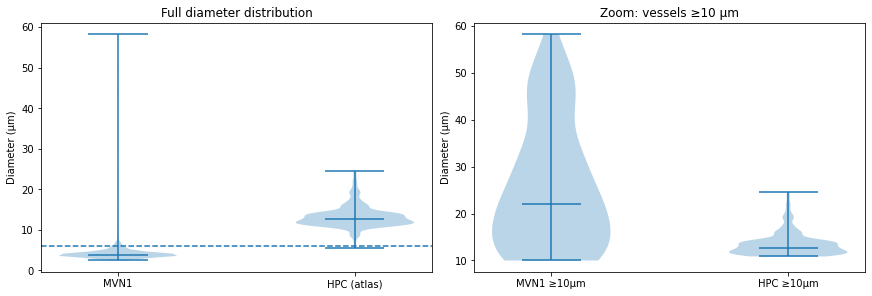

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Prepare data (µm)
# -------------------------
# MVN1 (SI -> µm)
d_m = np.asarray(Gm.es["diameter"], float) * 1e6
d_m = d_m[np.isfinite(d_m)]

# HPC (atlas-derived in µm)
d_h = np.asarray(Gp.es["diameter_atlas_R"], float)
d_h = d_h[np.isfinite(d_h)]

# Zoom threshold
zoom_thr = 10.0

d_m_zoom = d_m[d_m >= zoom_thr]
d_h_zoom = d_h[d_h >= zoom_thr]

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# ---- Panel 1: Full distribution ----
parts = axes[0].violinplot([d_m, d_h], showmeans=False, showmedians=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["MVN1", "HPC (atlas)"])
axes[0].set_ylabel("Diameter (µm)")
axes[0].set_title("Full diameter distribution")
axes[0].axhline(6, linestyle="--")  # capillary threshold

# ---- Panel 2: Zoom ≥10 µm ----
parts = axes[1].violinplot([d_m_zoom, d_h_zoom], showmeans=False, showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["MVN1 ≥10µm", "HPC ≥10µm"])
axes[1].set_ylabel("Diameter (µm)")
axes[1].set_title("Zoom: vessels ≥10 µm")

plt.show()

In [10]:
d_m = np.asarray(Gm.es["diameter"], float) * 1e6
d_m = d_m[np.isfinite(d_m)]

print("Max MVN1 diameter:", np.max(d_m))
print("Fraction >40 µm:", np.mean(d_m > 40))
print("Fraction >50 µm:", np.mean(d_m > 50))

k = np.asarray(Gm.es["nkind"])
large_mask = d_m > 40

print("nkind distribution for d>40 µm:")
print(np.unique(k[large_mask], return_counts=True))



Max MVN1 diameter: 58.238891602
Fraction >40 µm: 0.0014911772015574517
Fraction >50 µm: 0.0002485295335929086
nkind distribution for d>40 µm:
(array([0, 1]), array([ 2, 16]))


we can see that in MVN1 we have very high diameters. We checked to see if they are artifacts or real arteriole queues. 

Check how many are > 40 um & >50 um and also the nkind. The fraction is really low (~ 18/12000 > 40um) and are 0 and 1 (big vessels)

Conclusion: is a real artery queue. MVN1 contains a broader spectrum of vessel calibers, including larger arterial segments not present in the hippocampal atlas-derived network.

In [11]:
print("HPC min, max:", np.min(d_h_zoom), np.max(d_h_zoom))
print("MVN1 min, max:", np.min(d_m_zoom), np.max(d_m_zoom))

HPC min, max: 10.861809730529785 24.589466094970703
MVN1 min, max: 10.0 58.238891602


we conclude the absence of high caliber vessels in HPC

=== Diameter window: [10.0, 25.0] µm ===
MVN1: {'n': 52, 'p5': 10.03929042811, 'med': 15.586792468999999, 'p95': 24.0}
HPC : {'n': 1131, 'p5': 10.861809730529785, 'med': 12.736600875854492, 'p95': 19.201147079467773}
KS test (windowed): KstestResult(statistic=0.3806366047745358, pvalue=5.63469110621812e-07)


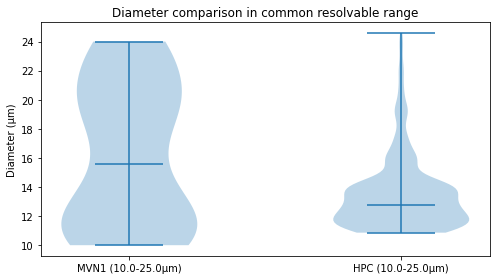

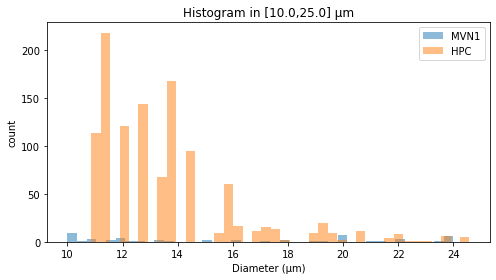

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

def clean(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def summarize(x):
    x = clean(x)
    if x.size == 0:
        return {"n": 0, "p5": np.nan, "med": np.nan, "p95": np.nan}
    return {
        "n": int(x.size),
        "p5": float(np.percentile(x, 5)),
        "med": float(np.median(x)),
        "p95": float(np.percentile(x, 95)),
    }

# ---------
# data (µm)
# ---------
d_m = clean(np.asarray(Gm.es["diameter"], float) * 1e6)         # MVN1 SI -> µm
d_h = clean(np.asarray(Gp.es["diameter_atlas_R"], float))       # HPC atlas -> µm

# -------------
# common window
# -------------
lo, hi = 10.0, 25.0
dm_w = d_m[(d_m >= lo) & (d_m <= hi)]
dh_w = d_h[(d_h >= lo) & (d_h <= hi)]

print(f"=== Diameter window: [{lo}, {hi}] µm ===")
print("MVN1:", summarize(dm_w))
print("HPC :", summarize(dh_w))

if dm_w.size and dh_w.size:
    ks = ks_2samp(dm_w, dh_w)
    print("KS test (windowed):", ks)

# ---------
# violin plot
# ---------
plt.figure(figsize=(7,4))
plt.violinplot([dm_w, dh_w], showmeans=False, showmedians=True, showextrema=True)
plt.xticks([1,2], [f"MVN1 ({lo}-{hi}µm)", f"HPC ({lo}-{hi}µm)"])
plt.ylabel("Diameter (µm)")
plt.title("Diameter comparison in common resolvable range")
plt.tight_layout()
plt.show()

# optional: overlay hist
plt.figure(figsize=(7,4))
plt.hist(dm_w, bins=40, alpha=0.5, label="MVN1")
plt.hist(dh_w, bins=40, alpha=0.5, label="HPC")
plt.xlabel("Diameter (µm)")
plt.ylabel("count")
plt.title(f"Histogram in [{lo},{hi}] µm")
plt.legend()
plt.tight_layout()
plt.show()
